In [14]:
import os
os.chdir("/Users/arunan/Desktop/visualization/02_activities/assignments")

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

print("\nFiles one level up:")
print(os.listdir(".."))


Current working directory:
/Users/arunan/Desktop/visualization/02_activities/assignments

Files in current directory:
['.Rhistory', '.DS_Store', 'assignment_2.md', 'assignment_3.ipynb', 'assignment_3.md', 'assignment_1.md', 'assignment_3', 'participation', 'Service Requests Tablaeu Image.pdf', 'SR2025.csv']

Files one level up:
['assignments', '.DS_Store']


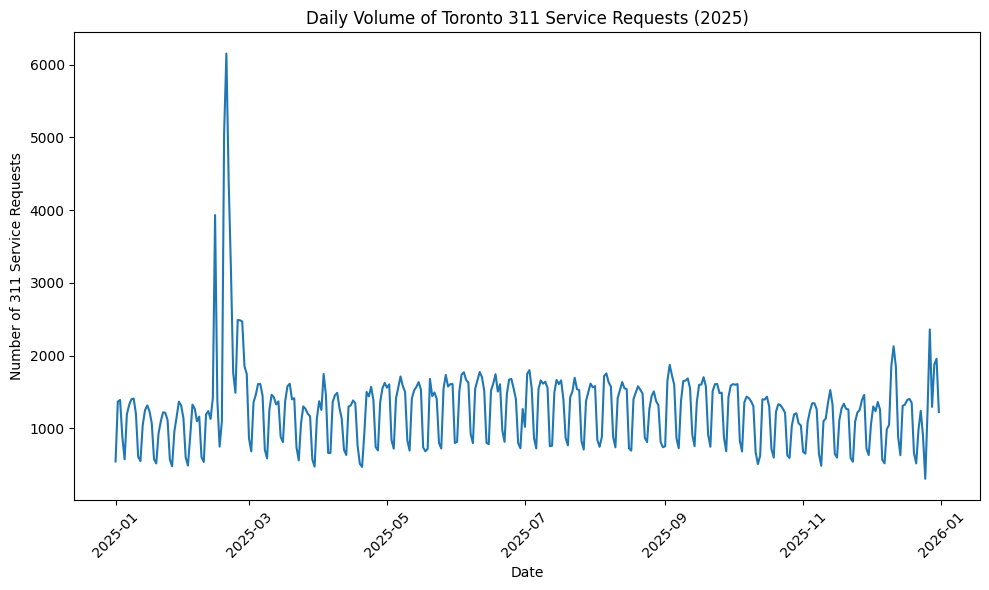

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(
    "/Users/arunan/Desktop/visualization/02_activities/assignments/SR2025.csv",
    encoding="latin1",
    on_bad_lines="skip"
)

# Convert 'Creation Date' column to datetime
df["Creation Date"] = pd.to_datetime(df["Creation Date"], errors="coerce")

# Drop invalid dates
df = df.dropna(subset=["Creation Date"])

# Aggregate number of service requests per day
daily_requests = (
    df
    .groupby(df["Creation Date"].dt.date)
    .size()
)

# Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(daily_requests.index, daily_requests.values)
plt.xlabel("Date")
plt.ylabel("Number of 311 Service Requests")
plt.title("Daily Volume of Toronto 311 Service Requests (2025)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
